# Phase 3.1 — SHAP Explainability

Explains the production IF + Autoencoder ensemble (Phase 2.2/2.3,
scored via backend/core/inference.py) with SHAP KernelExplainer:
global feature importance, plain-language per-player explanations
with engagement/tick traceability, and a check on whether Isolation
Forest and the autoencoder are genuinely catching different cheating
patterns or are just noisy versions of the same signal.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

BACKEND_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from core.inference import load_models, score_players
from core.model import FEATURE_ORDER, get_cleaned_train_test_data

df = pd.read_csv(BACKEND_DIR / "data" / "features_hybrid.csv")

X_train_cleaned, y_train_cleaned, X_test, y_test = get_cleaned_train_test_data()

# Reproduce idx_test -- the row indices into features_hybrid.csv that
# X_test/y_test correspond to (same split as core.model, never saved
# to disk) -- needed for engagement/tick traceability in Cell 7.
X_hybrid = df[FEATURE_ORDER].values
y_hybrid = df["label"].values
idx_all = np.arange(len(y_hybrid))
idx_train, idx_test = train_test_split(idx_all, test_size=0.2, stratify=y_hybrid, random_state=42)
assert np.allclose(X_hybrid[idx_test], X_test), "idx_test reconstruction mismatch"

models = load_models()

print(f"features_hybrid.csv shape: {df.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"idx_test shape: {idx_test.shape}")
print("Models loaded:", list(models.keys()))
print("scoring_config:", models["scoring_config"])

features_hybrid.csv shape: (12000, 18)
X_test shape: (2400, 11)
idx_test shape: (2400,)
Models loaded: ['iso_forest', 'autoencoder', 'scaler', 'scoring_config']
scoring_config: {'if_score_p1': -0.12177912083087014, 'if_score_p99': 0.08299678789178934, 'ae_score_p1': 0.015224658520892262, 'ae_score_p99': 1.8832051980495212, 'ensemble_weight_if': 0.3}


## score_fn wrapper for SHAP

In [2]:
def score_fn(X_array):
    """SHAP-compatible wrapper: raw (n, 11) unscaled feature array ->
    1D ensemble_score array. score_players() handles scaling
    internally via the loaded scaler."""
    X_df = pd.DataFrame(np.asarray(X_array), columns=FEATURE_ORDER)
    scores = score_players(X_df, models=models)
    return scores["ensemble_score"].values

# Sanity check against the raw scoring path.
_sanity = score_fn(X_test[:5])
print(f"score_fn sanity check (5 rows): {_sanity}")

score_fn sanity check (5 rows): [0.04353675 0.07189028 0.15761634 0.3200016  0.15387758]


## SHAP background dataset (100 legit-only training rows)

In [3]:
X_train_legit = X_train_cleaned[y_train_cleaned == 0]

rng = np.random.RandomState(42)
background_idx = rng.choice(len(X_train_legit), size=100, replace=False)
background = X_train_legit[background_idx]

print(f"X_train_legit shape: {X_train_legit.shape}")
print(f"background shape: {background.shape}")

X_train_legit shape: (7610, 11)
background shape: (100, 11)


## SHAP KernelExplainer on 30 test players\n\n15 highest-`ensemble_score` players + 15 random others (`random_state=42`). Timed -- if this exceeds 5 minutes, stop after this batch and report rather than silently changing approach (e.g. shrinking nsamples).

In [4]:
test_df = pd.DataFrame(X_test, columns=FEATURE_ORDER)
test_scores = score_players(test_df, models=models)

sorted_idx = np.argsort(test_scores["ensemble_score"].values)[::-1]
top15_idx = sorted_idx[:15]

remaining_idx = np.setdiff1d(np.arange(len(X_test)), top15_idx)
rng = np.random.RandomState(42)
random15_idx = rng.choice(remaining_idx, size=15, replace=False)

explain_idx = np.concatenate([top15_idx, random15_idx])
X_explain = X_test[explain_idx]

print(f"Explaining {len(explain_idx)} players "
      f"(15 highest ensemble_score + 15 random others).")
print(f"Highest ensemble_score among the 15 flagged: "
      f"{test_scores['ensemble_score'].values[top15_idx].max():.4f}")
print(f"Lowest ensemble_score among the 15 flagged:  "
      f"{test_scores['ensemble_score'].values[top15_idx].min():.4f}")

explainer = shap.KernelExplainer(score_fn, background)

start_time = time.time()
shap_values = explainer.shap_values(X_explain)
elapsed = time.time() - start_time

print()
print(f"SHAP computation for {len(X_explain)} players took {elapsed:.1f}s "
      f"({elapsed / 60:.2f} min).")
if elapsed > 300:
    print("WARNING: exceeded 5 minutes -- stopping here per instructions, "
          "reporting timing without proceeding further.")
else:
    print("Within the 5-minute budget -- proceeding.")

shap_values = np.asarray(shap_values)
print(f"shap_values shape: {shap_values.shape}")

Explaining 30 players (15 highest ensemble_score + 15 random others).
Highest ensemble_score among the 15 flagged: 1.0000
Lowest ensemble_score among the 15 flagged:  0.9078


  0%|          | 0/30 [00:00<?, ?it/s]


SHAP computation for 30 players took 51.6s (0.86 min).
Within the 5-minute budget -- proceeding.
shap_values shape: (30, 11)


## Global feature importance (SHAP summary plot)

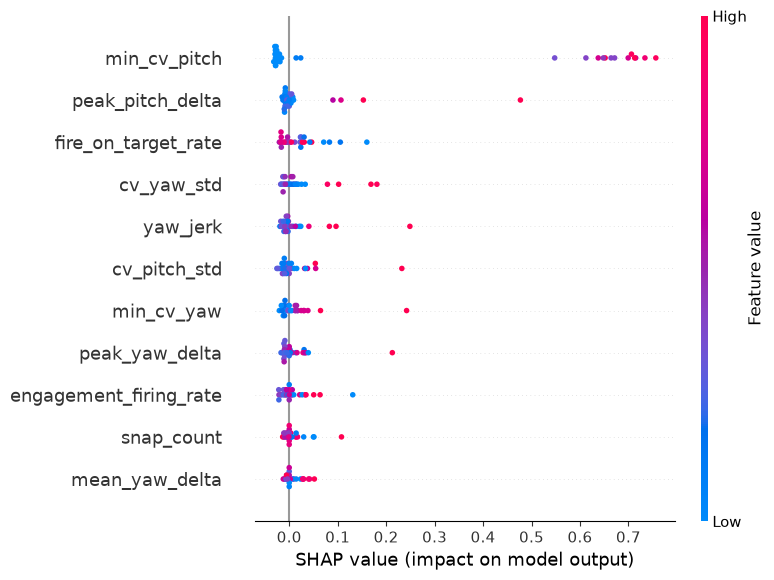

Saved D:\ARGUS\backend\notebooks\shap_summary_plot.png

feature                     mean |SHAP value|
----------------------------------------------
min_cv_pitch                          0.30593
peak_pitch_delta                      0.03309
fire_on_target_rate                   0.02950
cv_yaw_std                            0.02736
yaw_jerk                              0.02383
cv_pitch_std                          0.02296
min_cv_yaw                            0.02243
peak_yaw_delta                        0.01956
engagement_firing_rate                0.01861
snap_count                            0.01353
mean_yaw_delta                        0.01170


In [5]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_explain, feature_names=FEATURE_ORDER, show=False)
plt.tight_layout()

plot_path = Path("shap_summary_plot.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved {plot_path.resolve()}")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_order = np.argsort(mean_abs_shap)[::-1]

print()
print(f"{'feature':<26} {'mean |SHAP value|':>18}")
print("-" * 46)
for i in importance_order:
    print(f"{FEATURE_ORDER[i]:<26} {mean_abs_shap[i]:>18.5f}")

## Plain-language feature description templates

In [6]:
FEATURE_DESCRIPTIONS = {
    "peak_yaw_delta": "Aim snapped {value:.1f}\u00b0 in a single tick (~15.6ms)",
    "peak_pitch_delta": "Aim pitch snapped {value:.1f}\u00b0 vertically in a single tick (~15.6ms)",
    "mean_yaw_delta": "Averaged {value:.2f}\u00b0 of horizontal aim movement per tick across the engagement",
    "snap_count": "{value:.0f} sudden aim snaps detected during the engagement",
    "min_cv_yaw": "Got as close as {value:.2f}\u00b0 from the target's horizontal position",
    "min_cv_pitch": "Got as close as {value:.2f}\u00b0 from the target's vertical position",
    "cv_yaw_std": "Horizontal aim-to-target distance varied by {value:.2f}\u00b0 (std dev) across the engagement",
    "cv_pitch_std": "Vertical aim-to-target distance varied by {value:.2f}\u00b0 (std dev) across the engagement",
    "fire_on_target_rate": "{value:.0%} of shots fired while aimed within 2\u00b0 of the target",
    "yaw_jerk": "Aim direction changed abruptly, averaging {value:.2f}\u00b0/tick\u00b2 of horizontal jerk",
    "engagement_firing_rate": "Fired on {value:.0%} of ticks during the engagement",
}

assert set(FEATURE_DESCRIPTIONS.keys()) == set(FEATURE_ORDER), "description coverage mismatch"

for feat in FEATURE_ORDER:
    print(f"{feat}: {FEATURE_DESCRIPTIONS[feat]}")

peak_yaw_delta: Aim snapped {value:.1f}° in a single tick (~15.6ms)
peak_pitch_delta: Aim pitch snapped {value:.1f}° vertically in a single tick (~15.6ms)
mean_yaw_delta: Averaged {value:.2f}° of horizontal aim movement per tick across the engagement
snap_count: {value:.0f} sudden aim snaps detected during the engagement
min_cv_yaw: Got as close as {value:.2f}° from the target's horizontal position
min_cv_pitch: Got as close as {value:.2f}° from the target's vertical position
cv_yaw_std: Horizontal aim-to-target distance varied by {value:.2f}° (std dev) across the engagement
cv_pitch_std: Vertical aim-to-target distance varied by {value:.2f}° (std dev) across the engagement
fire_on_target_rate: {value:.0%} of shots fired while aimed within 2° of the target
yaw_jerk: Aim direction changed abruptly, averaging {value:.2f}°/tick² of horizontal jerk
engagement_firing_rate: Fired on {value:.0%} of ticks during the engagement


## Full explanation for the 3 highest-scoring flagged players\n\nAmong the 30 explained players: player_id (original features_hybrid.csv row), ensemble_score, if_score, ae_score, top 5 SHAP features with plain-language sentences, plus engagement/tick traceability for peak_yaw_delta and min_cv_yaw.

In [7]:
TRACEABLE_FEATURES = {"peak_yaw_delta", "min_cv_yaw"}

explain_scores = test_scores.iloc[explain_idx].reset_index(drop=True)

flagged_order = np.argsort(explain_scores["ensemble_score"].values)[::-1][:3]

for rank, j in enumerate(flagged_order, start=1):
    row_pos = explain_idx[j]              # position in X_test
    hybrid_row_idx = idx_test[row_pos]     # original features_hybrid.csv row
    hybrid_row = df.iloc[hybrid_row_idx]

    ensemble_score = explain_scores.loc[j, "ensemble_score"]
    if_score = explain_scores.loc[j, "if_score"]
    ae_score = explain_scores.loc[j, "ae_score"]
    true_label = "CHEATER" if y_test[row_pos] == 1 else "legit"

    top5_idx = np.argsort(np.abs(shap_values[j]))[::-1][:5]

    print("=" * 78)
    print(f"Flagged player #{rank} -- player_id (features_hybrid.csv row): {hybrid_row_idx} "
          f"[ground truth: {true_label}]")
    print(f"  ensemble_score: {ensemble_score:.4f}   "
          f"if_score: {if_score:.4f}   ae_score: {ae_score:.4f}")
    print("  Top 5 contributing features:")
    for i in top5_idx:
        feat = FEATURE_ORDER[i]
        value = X_explain[j, i]
        shap_val = shap_values[j, i]
        sentence = FEATURE_DESCRIPTIONS[feat].format(value=value)
        if feat in TRACEABLE_FEATURES:
            eng = hybrid_row[f"{feat}_source_engagement"]
            tick = hybrid_row[f"{feat}_source_tick"]
            t_sec = hybrid_row[f"{feat}_real_time_seconds"]
            sentence += f" (seen in engagement {eng:.0f}, at the {t_sec:.2f}s mark)"
        print(f"    - {sentence}  [SHAP={shap_val:+.4f}]")
    print()

Flagged player #1 -- player_id (features_hybrid.csv row): 7237 [ground truth: legit]
  ensemble_score: 1.0000   if_score: 1.0000   ae_score: 1.0000
  Top 5 contributing features:
    - Got as close as 0.02° from the target's vertical position  [SHAP=+0.7061]
    - 0 sudden aim snaps detected during the engagement  [SHAP=+0.0499]
    - Aim snapped 11.6° in a single tick (~15.6ms) (seen in engagement 29, at the 0.83s mark)  [SHAP=+0.0394]
    - Fired on 7% of ticks during the engagement  [SHAP=+0.0347]
    - Horizontal aim-to-target distance varied by 15.28° (std dev) across the engagement  [SHAP=+0.0255]

Flagged player #2 -- player_id (features_hybrid.csv row): 356 [ground truth: CHEATER]
  ensemble_score: 1.0000   if_score: 1.0000   ae_score: 1.0000
  Top 5 contributing features:
    - Aim pitch snapped 92.1° vertically in a single tick (~15.6ms)  [SHAP=+0.4770]
    - 32% of shots fired while aimed within 2° of the target  [SHAP=+0.1602]
    - Fired on 3% of ticks during the engagemen

## IF vs AE disagreement check\n\nAcross all 30 explained players: correlation between if_score and ae_score, and the player(s) where they disagree most -- checks whether the two models catch genuinely different patterns (per the Phase 2.3 hypothesis) or are noisy versions of the same signal.

In [8]:
corr = np.corrcoef(explain_scores["if_score"], explain_scores["ae_score"])[0, 1]
print(f"IF vs AE score correlation across the 30 explained players: {corr:.4f}")

if corr < 0.3:
    interp = "genuinely complementary -- the two models are catching largely different signal"
elif corr < 0.7:
    interp = "partially complementary -- meaningful shared signal but real disagreement too"
else:
    interp = "largely redundant -- the two models are mostly agreeing / noisy versions of the same signal"
print(f"Interpretation: {interp}.")

disagreement = (explain_scores["if_score"] - explain_scores["ae_score"]).abs()
disagreement_order = np.argsort(disagreement.values)[::-1]

print()
print("Most-disagreeing players (|if_score - ae_score|):")
for rank, j in enumerate(disagreement_order[:3], start=1):
    row_pos = explain_idx[j]
    hybrid_row_idx = idx_test[row_pos]
    true_label = "CHEATER" if y_test[row_pos] == 1 else "legit"
    print(f"  #{rank}: player_id={hybrid_row_idx} [{true_label}]  "
          f"if_score={explain_scores.loc[j, 'if_score']:.4f}  "
          f"ae_score={explain_scores.loc[j, 'ae_score']:.4f}  "
          f"diff={disagreement.iloc[j]:.4f}  "
          f"ensemble_score={explain_scores.loc[j, 'ensemble_score']:.4f}")

IF vs AE score correlation across the 30 explained players: 0.9290
Interpretation: largely redundant -- the two models are mostly agreeing / noisy versions of the same signal.

Most-disagreeing players (|if_score - ae_score|):
  #1: player_id=10220 [legit]  if_score=0.7282  ae_score=0.1945  diff=0.5337  ensemble_score=0.3546
  #2: player_id=4396 [legit]  if_score=0.3432  ae_score=0.0136  diff=0.3295  ensemble_score=0.1125
  #3: player_id=10128 [legit]  if_score=0.3210  ae_score=0.0198  diff=0.3012  ensemble_score=0.1102


## Phase 3.1.5 — Cross-check: surrogate RandomForestRegressor + TreeExplainer\n\nKernelExplainer is a perturbation-based method and can behave oddly on heavily floor-skewed features (most values near 0 for both classes, like min_cv_pitch). TreeExplainer on a surrogate tree trained to mimic the ensemble's output tends to handle skew more calibratedly. This is a complementary check, not a replacement for the Cell 5 result.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

surrogate_model = RandomForestRegressor(n_estimators=200, random_state=42)
surrogate_model.fit(X_test, test_scores["ensemble_score"].values)

surrogate_pred = surrogate_model.predict(X_test)
surrogate_r2 = r2_score(test_scores["ensemble_score"].values, surrogate_pred)

print(f"Surrogate RandomForestRegressor R\u00b2 vs actual ensemble_score: {surrogate_r2:.4f}")
if surrogate_r2 < 0.7:
    print("WARNING: R\u00b2 < 0.7 -- the surrogate does not mimic the ensemble well "
          "enough to trust its SHAP values as a cross-check.")
else:
    print("Surrogate fit is good enough (R\u00b2 >= 0.7) to trust its SHAP values "
          "as a cross-check.")

Surrogate RandomForestRegressor R² vs actual ensemble_score: 0.9832
Surrogate fit is good enough (R² >= 0.7) to trust its SHAP values as a cross-check.


In [10]:
tree_explainer = shap.TreeExplainer(surrogate_model)
tree_shap_values = tree_explainer.shap_values(X_explain)
tree_shap_values = np.asarray(tree_shap_values)

print(f"tree_shap_values shape: {tree_shap_values.shape}")

tree_mean_abs_shap = np.abs(tree_shap_values).mean(axis=0)
tree_importance_order = np.argsort(tree_mean_abs_shap)[::-1]

print()
print(f"{'feature':<26} {'mean |SHAP value| (Tree)':>26}")
print("-" * 54)
for i in tree_importance_order:
    print(f"{FEATURE_ORDER[i]:<26} {tree_mean_abs_shap[i]:>26.5f}")

tree_shap_values shape: (30, 11)

feature                      mean |SHAP value| (Tree)
------------------------------------------------------
min_cv_pitch                                  0.32389
cv_yaw_std                                    0.02173
peak_pitch_delta                              0.01717
fire_on_target_rate                           0.01556
cv_pitch_std                                  0.01392
peak_yaw_delta                                0.01324
yaw_jerk                                      0.01156
min_cv_yaw                                    0.00983
mean_yaw_delta                                0.00952
engagement_firing_rate                        0.00909
snap_count                                    0.00792


In [11]:
print(f"{'feature':<26} {'KernelExplainer |SHAP|':>24} {'TreeExplainer |SHAP|':>24}")
print("-" * 76)
for i in importance_order:
    print(f"{FEATURE_ORDER[i]:<26} {mean_abs_shap[i]:>24.5f} {tree_mean_abs_shap[i]:>24.5f}")

min_cv_pitch_idx = FEATURE_ORDER.index("min_cv_pitch")

kernel_others = np.delete(mean_abs_shap, min_cv_pitch_idx)
kernel_dominance_ratio = mean_abs_shap[min_cv_pitch_idx] / kernel_others.max()

tree_others = np.delete(tree_mean_abs_shap, min_cv_pitch_idx)
tree_dominance_ratio = tree_mean_abs_shap[min_cv_pitch_idx] / tree_others.max()

tree_rank = int(np.where(tree_importance_order == min_cv_pitch_idx)[0][0]) + 1

print()
print(f"min_cv_pitch dominance ratio (importance / 2nd-highest feature\'s importance):")
print(f"  KernelExplainer: {kernel_dominance_ratio:.2f}x  "
      f"(min_cv_pitch={mean_abs_shap[min_cv_pitch_idx]:.5f}, "
      f"runner-up={kernel_others.max():.5f})")
print(f"  TreeExplainer:   {tree_dominance_ratio:.2f}x  "
      f"(min_cv_pitch={tree_mean_abs_shap[min_cv_pitch_idx]:.5f}, "
      f"runner-up={tree_others.max():.5f}, rank #{tree_rank})")

ratio_of_ratios = tree_dominance_ratio / kernel_dominance_ratio
print()
if ratio_of_ratios >= 1.2:
    conclusion = ("TreeExplainer shows an EQUALLY LARGE OR LARGER dominance ratio than "
                   "KernelExplainer -- min_cv_pitch's dominance is GENUINE, not a "
                   "KernelExplainer artifact, and if anything the skew-robust method "
                   "finds it even more pronounced.")
elif ratio_of_ratios >= 0.7:
    conclusion = ("TreeExplainer shows a SIMILAR dominance ratio to KernelExplainer -- "
                   "min_cv_pitch's dominance looks GENUINE, not a KernelExplainer artifact.")
elif ratio_of_ratios >= 0.3:
    conclusion = ("TreeExplainer shows a SMALLER but still substantial dominance ratio -- "
                   "the effect is real but KernelExplainer likely INFLATED its magnitude "
                   "somewhat on this floor-skewed feature.")
else:
    conclusion = ("TreeExplainer shows a MUCH SMALLER dominance ratio -- "
                   "min_cv_pitch's ~9x dominance under KernelExplainer looks largely like "
                   "a perturbation-method ARTIFACT on this floor-skewed feature, not a "
                   "genuine effect of that magnitude.")
print(conclusion)

feature                      KernelExplainer |SHAP|     TreeExplainer |SHAP|
----------------------------------------------------------------------------
min_cv_pitch                                0.30593                  0.32389
peak_pitch_delta                            0.03309                  0.01717
fire_on_target_rate                         0.02950                  0.01556
cv_yaw_std                                  0.02736                  0.02173
yaw_jerk                                    0.02383                  0.01156
cv_pitch_std                                0.02296                  0.01392
min_cv_yaw                                  0.02243                  0.00983
peak_yaw_delta                              0.01956                  0.01324
engagement_firing_rate                      0.01861                  0.00909
snap_count                                  0.01353                  0.00792
mean_yaw_delta                              0.01170                  0.00952